<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/9th_April_Na%C3%AFve_bayes_1_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### Data Science Masters


## Q1. What is Bayes' Theorem?

**Bayes' Theorem** is a fundamental concept in probability theory and statistics that describes how to update the probability of a hypothesis (belief) given new evidence.

It was formulated by **Reverend Thomas Bayes** in the 18th century and published posthumously in 1763.

### Key Concepts:
- **Prior Probability**: What we believe before seeing evidence — P(H)
- **Likelihood**: How probable the evidence is given the hypothesis — P(E|H)
- **Posterior Probability**: Updated belief after seeing evidence — P(H|E)
- **Marginal Likelihood**: Total probability of the evidence — P(E)

### Intuition:
> *"Bayes' theorem tells us how to rationally update our beliefs when we encounter new evidence."*

**Example**: If a patient tests positive for a rare disease, Bayes' theorem helps calculate the actual probability that the patient truly has the disease — taking into account both the test accuracy and how rare the disease is in the population.

---
## Q2. What is the Formula for Bayes' Theorem?

The mathematical formula is:

$$P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}$$

Where:
| Symbol | Name | Meaning |
|--------|------|---------|
| P(H\|E) | **Posterior** | Probability of hypothesis H given evidence E |
| P(E\|H) | **Likelihood** | Probability of evidence E given hypothesis H |
| P(H)   | **Prior**      | Initial probability of hypothesis H |
| P(E)   | **Evidence**   | Total probability of evidence E (normalizer) |

### Expanded Form:
$$P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E|H) \cdot P(H) + P(E|\neg H) \cdot P(\neg H)}$$

### For Multiple Classes (used in Naive Bayes):
$$P(C_k | x_1, x_2, ..., x_n) \propto P(C_k) \cdot \prod_{i=1}^{n} P(x_i | C_k)$$

In [1]:
# Demonstrating Bayes' Theorem Formula with a simple example

def bayes_theorem(prior, likelihood, evidence):
    """
    Calculate posterior probability using Bayes' Theorem.

    Args:
        prior     : P(H)   - Prior probability of hypothesis
        likelihood: P(E|H) - Likelihood of evidence given hypothesis
        evidence  : P(E)   - Marginal probability of evidence

    Returns:
        P(H|E) - Posterior probability
    """
    posterior = (likelihood * prior) / evidence
    return posterior

# Example: Medical Test
# Disease prevalence: 1% of population has the disease
# Test sensitivity: 99% (correctly detects disease)
# Test specificity: 95% (correctly identifies healthy people)

P_disease    = 0.01           # Prior: P(Disease)
P_no_disease = 1 - P_disease  # P(No Disease)
P_pos_given_disease    = 0.99  # Likelihood: P(Positive | Disease)
P_pos_given_no_disease = 0.05  # P(Positive | No Disease) = 1 - specificity

# Total probability of a positive test: P(E)
P_positive = (P_pos_given_disease * P_disease) + (P_pos_given_no_disease * P_no_disease)

# Posterior: P(Disease | Positive Test)
posterior = bayes_theorem(P_disease, P_pos_given_disease, P_positive)

print("=" * 55)
print("       BAYES' THEOREM — MEDICAL TEST EXAMPLE")
print("=" * 55)
print(f"  Prior P(Disease)             : {P_disease:.2%}")
print(f"  Likelihood P(+ve | Disease)  : {P_pos_given_disease:.2%}")
print(f"  Marginal P(Positive)         : {P_positive:.4f}")
print("-" * 55)
print(f"  Posterior P(Disease | +ve)   : {posterior:.2%}")
print("=" * 55)
print(f"\n  Even with a 99% accurate test, a positive result")
print(f"  only means ~{posterior:.0%} chance of actually having")
print(f"  the disease (due to the disease being rare).")

       BAYES' THEOREM — MEDICAL TEST EXAMPLE
  Prior P(Disease)             : 1.00%
  Likelihood P(+ve | Disease)  : 99.00%
  Marginal P(Positive)         : 0.0594
-------------------------------------------------------
  Posterior P(Disease | +ve)   : 16.67%

  Even with a 99% accurate test, a positive result
  only means ~17% chance of actually having
  the disease (due to the disease being rare).


---
## Q3. How is Bayes' Theorem Used in Practice?

Bayes' Theorem has widespread real-world applications:

### 1. 📧 Spam Filtering
- Classify emails as spam or not-spam based on the words they contain
- P(Spam | words) ∝ P(words | Spam) × P(Spam)

### 2. 🏥 Medical Diagnosis
- Estimate disease probability given test results and patient symptoms
- Accounts for base rates of diseases in the population

### 3. 🤖 Machine Learning (Naive Bayes Classifiers)
- Text classification, sentiment analysis, document categorization
- Fast, interpretable, and works well with small datasets

### 4. 🔍 Search Engines & Recommendation Systems
- Rank documents based on relevance probabilities
- Personalize recommendations based on user behavior

### 5. 🎯 A/B Testing & Bayesian Inference
- Update beliefs about which variant is better as more data arrives

### 6. 🔒 Fraud Detection
- Estimate probability of fraud given transaction patterns

### 7. 🌤️ Weather Forecasting
- Update weather predictions as new meteorological data comes in

In [2]:
# Practical Example: Simple Spam Filter using Bayes' Theorem

# Training data probabilities (simplified)
# P(word | Spam) and P(word | Ham)
word_probs = {
    'free':    {'spam': 0.80, 'ham': 0.10},
    'winner':  {'spam': 0.70, 'ham': 0.05},
    'meeting': {'spam': 0.05, 'ham': 0.60},
    'offer':   {'spam': 0.65, 'ham': 0.15},
    'report':  {'spam': 0.02, 'ham': 0.55},
}

P_spam = 0.3  # Prior: 30% of emails are spam
P_ham  = 0.7  # Prior: 70% of emails are ham

def classify_email(words):
    log_prob_spam = __import__('math').log(P_spam)
    log_prob_ham  = __import__('math').log(P_ham)

    for word in words:
        if word in word_probs:
            log_prob_spam += __import__('math').log(word_probs[word]['spam'])
            log_prob_ham  += __import__('math').log(word_probs[word]['ham'])

    return 'SPAM' if log_prob_spam > log_prob_ham else 'HAM (Not Spam)'

# Test emails
emails = {
    'Email 1': ['free', 'winner', 'offer'],
    'Email 2': ['meeting', 'report'],
    'Email 3': ['free', 'meeting'],
}

print("=" * 40)
print("     NAIVE BAYES SPAM FILTER")
print("=" * 40)
for email, words in emails.items():
    result = classify_email(words)
    print(f"  {email} {words}")
    print(f"    → Classified as: {result}")
    print()

     NAIVE BAYES SPAM FILTER
  Email 1 ['free', 'winner', 'offer']
    → Classified as: SPAM

  Email 2 ['meeting', 'report']
    → Classified as: HAM (Not Spam)

  Email 3 ['free', 'meeting']
    → Classified as: HAM (Not Spam)



---
## Q4. Relationship Between Bayes' Theorem and Conditional Probability

Bayes' Theorem is **derived directly from the definition of conditional probability**.

### Conditional Probability Definition:
$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

### Derivation of Bayes' Theorem:

**Step 1**: From the definition of conditional probability:
$$P(A|B) = \frac{P(A \cap B)}{P(B)} \quad \text{and} \quad P(B|A) = \frac{P(B \cap A)}{P(A)}$$

**Step 2**: Since $P(A \cap B) = P(B \cap A)$, we get:
$$P(A \cap B) = P(B|A) \cdot P(A)$$

**Step 3**: Substituting back:
$$\boxed{P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}}$$

### Key Relationship Summary:
| Concept | Formula | Role |
|---------|---------|------|
| Conditional Probability | P(A\|B) = P(A∩B)/P(B) | Foundation |
| Joint Probability | P(A∩B) = P(A\|B)·P(B) | Bridge |
| Bayes' Theorem | P(A\|B) = P(B\|A)·P(A)/P(B) | Derived Result |

> **Bayes' theorem is essentially a way to "flip" a conditional probability** — it lets us calculate P(H|E) when we know P(E|H), which is often easier to measure.

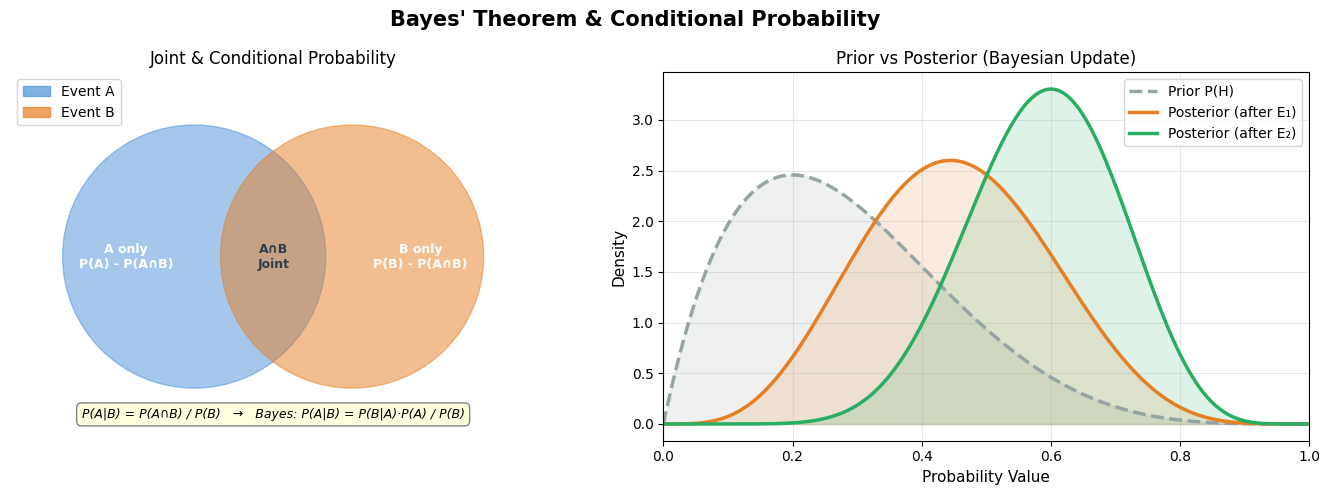

Visualization saved!


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Visual demonstration: Venn diagram of conditional probability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Bayes' Theorem & Conditional Probability", fontsize=15, fontweight='bold')

# --- Plot 1: Venn Diagram ---
ax1 = axes[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 7)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title("Joint & Conditional Probability", fontsize=12)

circle_A = plt.Circle((3.5, 3.5), 2.5, color='#4A90D9', alpha=0.5, label='P(A)')
circle_B = plt.Circle((6.5, 3.5), 2.5, color='#E67E22', alpha=0.5, label='P(B)')
ax1.add_patch(circle_A)
ax1.add_patch(circle_B)

ax1.text(2.2, 3.5, 'A only\nP(A) - P(A∩B)', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
ax1.text(7.8, 3.5, 'B only\nP(B) - P(A∩B)', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
ax1.text(5.0, 3.5, 'A∩B\nJoint', ha='center', va='center', fontsize=9, fontweight='bold', color='#2C3E50')

ax1.text(5.0, 0.5, 'P(A|B) = P(A∩B) / P(B)   →   Bayes: P(A|B) = P(B|A)·P(A) / P(B)',
         ha='center', va='center', fontsize=9, style='italic',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray'))

legend_elements = [mpatches.Patch(color='#4A90D9', alpha=0.7, label='Event A'),
                   mpatches.Patch(color='#E67E22', alpha=0.7, label='Event B')]
ax1.legend(handles=legend_elements, loc='upper left')

# --- Plot 2: Prior vs Posterior ---
ax2 = axes[1]
ax2.set_title("Prior vs Posterior (Bayesian Update)", fontsize=12)

p_values = np.linspace(0, 1, 200)
# Simulate: Beta distribution for prior and posterior
from scipy.stats import beta

prior = beta.pdf(p_values, 2, 5)         # Prior belief (biased toward low probability)
posterior_1 = beta.pdf(p_values, 5, 6)   # After some evidence
posterior_2 = beta.pdf(p_values, 10, 7)  # After more evidence

ax2.plot(p_values, prior,       label='Prior P(H)',          color='#95A5A6', linewidth=2.5, linestyle='--')
ax2.plot(p_values, posterior_1, label='Posterior (after E₁)', color='#E67E22', linewidth=2.5)
ax2.plot(p_values, posterior_2, label='Posterior (after E₂)', color='#27AE60', linewidth=2.5)

ax2.fill_between(p_values, prior,       alpha=0.15, color='#95A5A6')
ax2.fill_between(p_values, posterior_1, alpha=0.15, color='#E67E22')
ax2.fill_between(p_values, posterior_2, alpha=0.15, color='#27AE60')

ax2.set_xlabel('Probability Value', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 1)

plt.tight_layout()
plt.savefig('bayes_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved!")

---
## Q5. How Do You Choose Which Type of Naive Bayes Classifier to Use?

There are **three main types** of Naive Bayes classifiers. The choice depends on the **nature of your features**:

---

### 1. 🔢 Gaussian Naive Bayes
**Use when**: Features are **continuous** and approximately **normally distributed**

$$P(x_i | C_k) = \frac{1}{\sqrt{2\pi\sigma_k^2}} \exp\left(-\frac{(x_i - \mu_k)^2}{2\sigma_k^2}\right)$$

- ✅ Height, weight, temperature, sensor readings
- ✅ Medical features like blood pressure
- ❌ Not for text or count data

---

### 2. 🎯 Multinomial Naive Bayes
**Use when**: Features represent **counts or frequencies** (non-negative integers)

$$P(x_i | C_k) = \frac{(\sum_j x_j)!}{\prod_j x_j!} \prod_j p_{ki}^{x_i}$$

- ✅ Word counts in text classification (TF or TF-IDF)
- ✅ Spam filtering, news categorization
- ✅ Document frequency features
- ❌ Not for negative or continuous values

---

### 3. ⚖️ Bernoulli Naive Bayes
**Use when**: Features are **binary** (0 or 1, True or False, Present or Absent)

$$P(x_i | C_k) = p_{ki}^{x_i} (1 - p_{ki})^{(1 - x_i)}$$

- ✅ Whether a word appears or not (not how many times)
- ✅ Binary feature vectors
- ✅ Short text classification
- ❌ Not for multi-valued or continuous features

---

### Decision Guide:

```
What type are your features?
│
├── Continuous / Real-valued? ──────────────→ Gaussian Naive Bayes
│
├── Counts / Frequencies (integers ≥ 0)? ──→ Multinomial Naive Bayes
│
└── Binary / Boolean (0 or 1)? ────────────→ Bernoulli Naive Bayes
```

| Classifier | Feature Type | Common Use Case |
|-----------|-------------|------------------|
| **Gaussian NB** | Continuous (real-valued) | Medical data, sensor readings |
| **Multinomial NB** | Discrete counts | Text classification, NLP |
| **Bernoulli NB** | Binary (0/1) | Short texts, binary features |

---
## Q6. Assignment: Naive Bayes Classification

### Problem Statement
Given a dataset with two features **X1** and **X2**, and two classes **A** and **B**, classify a new instance with **X1=3** and **X2=4** using Naive Bayes.

### Frequency Table:

| Class | X1=1 | X1=2 | X1=3 | X2=1 | X2=2 | X2=3 | X2=4 |
|-------|------|------|------|------|------|------|------|
| **A** |  3   |  3   |  4   |  4   |  3   |  3   |  3   |
| **B** |  2   |  2   |  1   |  2   |  2   |  2   |  3   |

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


#  STEP 1: Define the Frequency Table from the problem

freq_data = {
    'Class': ['A', 'B'],
    'X1=1': [3, 2],
    'X1=2': [3, 2],
    'X1=3': [4, 1],
    'X2=1': [4, 2],
    'X2=2': [3, 2],
    'X2=3': [3, 2],
    'X2=4': [3, 3],
}

df = pd.DataFrame(freq_data).set_index('Class')
print("Frequency Table:")
print("=" * 55)
print(df.to_string())
print()

Frequency Table:
       X1=1  X1=2  X1=3  X2=1  X2=2  X2=3  X2=4
Class                                          
A         3     3     4     4     3     3     3
B         2     2     1     2     2     2     3



In [5]:
#  STEP 2: Calculate Prior Probabilities

# Equal prior probabilities (given in the problem)
P_A = 0.5
P_B = 0.5

print("=" * 55)
print("STEP 2: Prior Probabilities (Equal)")
print("=" * 55)
print(f"  P(Class = A) = {P_A}")
print(f"  P(Class = B) = {P_B}")

STEP 2: Prior Probabilities (Equal)
  P(Class = A) = 0.5
  P(Class = B) = 0.5


In [6]:

#  STEP 3: Calculate Likelihoods for X1 and X2


# --- Class A ---
# Total counts for X1 in class A
X1_total_A = df.loc['A', ['X1=1', 'X1=2', 'X1=3']].sum()
# Total counts for X2 in class A
X2_total_A = df.loc['A', ['X2=1', 'X2=2', 'X2=3', 'X2=4']].sum()

# --- Class B ---
# Total counts for X1 in class B
X1_total_B = df.loc['B', ['X1=1', 'X1=2', 'X1=3']].sum()
# Total counts for X2 in class B
X2_total_B = df.loc['B', ['X2=1', 'X2=2', 'X2=3', 'X2=4']].sum()

# --- Likelihoods for new instance (X1=3, X2=4) ---
# P(X1=3 | A)
P_X1_3_given_A = df.loc['A', 'X1=3'] / X1_total_A
# P(X2=4 | A)
P_X2_4_given_A = df.loc['A', 'X2=4'] / X2_total_A
# P(X1=3 | B)
P_X1_3_given_B = df.loc['B', 'X1=3'] / X1_total_B
# P(X2=4 | B)
P_X2_4_given_B = df.loc['B', 'X2=4'] / X2_total_B

print("=" * 55)
print("STEP 3: Likelihood Calculations")
print("=" * 55)
print(f"  Class A:")
print(f"    Total X1 frequencies : {X1_total_A}")
print(f"    Total X2 frequencies : {X2_total_A}")
print(f"    P(X1=3 | A) = {df.loc['A','X1=3']} / {X1_total_A} = {P_X1_3_given_A:.4f}")
print(f"    P(X2=4 | A) = {df.loc['A','X2=4']} / {X2_total_A} = {P_X2_4_given_A:.4f}")
print()
print(f"  Class B:")
print(f"    Total X1 frequencies : {X1_total_B}")
print(f"    Total X2 frequencies : {X2_total_B}")
print(f"    P(X1=3 | B) = {df.loc['B','X1=3']} / {X1_total_B} = {P_X1_3_given_B:.4f}")
print(f"    P(X2=4 | B) = {df.loc['B','X2=4']} / {X2_total_B} = {P_X2_4_given_B:.4f}")

STEP 3: Likelihood Calculations
  Class A:
    Total X1 frequencies : 10
    Total X2 frequencies : 13
    P(X1=3 | A) = 4 / 10 = 0.4000
    P(X2=4 | A) = 3 / 13 = 0.2308

  Class B:
    Total X1 frequencies : 5
    Total X2 frequencies : 9
    P(X1=3 | B) = 1 / 5 = 0.2000
    P(X2=4 | B) = 3 / 9 = 0.3333


In [7]:

#  STEP 4: Calculate Posterior Probabilities (Unnormalized)
#          Using Naive Bayes (feature independence assumption)
#          P(C|X1,X2) ∝ P(X1|C) * P(X2|C) * P(C)


# Unnormalized posteriors
score_A = P_X1_3_given_A * P_X2_4_given_A * P_A
score_B = P_X1_3_given_B * P_X2_4_given_B * P_B

# Normalized posteriors
total = score_A + score_B
posterior_A = score_A / total
posterior_B = score_B / total

print("=" * 55)
print("STEP 4: Posterior Scores (Naive Bayes)")
print("=" * 55)
print(f"  Score(A) = P(X1=3|A) × P(X2=4|A) × P(A)")
print(f"           = {P_X1_3_given_A:.4f} × {P_X2_4_given_A:.4f} × {P_A}")
print(f"           = {score_A:.6f}")
print()
print(f"  Score(B) = P(X1=3|B) × P(X2=4|B) × P(B)")
print(f"           = {P_X1_3_given_B:.4f} × {P_X2_4_given_B:.4f} × {P_B}")
print(f"           = {score_B:.6f}")
print()
print("-" * 55)
print(f"  Normalized Posterior P(A | X1=3, X2=4) = {posterior_A:.4f} ({posterior_A:.2%})")
print(f"  Normalized Posterior P(B | X1=3, X2=4) = {posterior_B:.4f} ({posterior_B:.2%})")

STEP 4: Posterior Scores (Naive Bayes)
  Score(A) = P(X1=3|A) × P(X2=4|A) × P(A)
           = 0.4000 × 0.2308 × 0.5
           = 0.046154

  Score(B) = P(X1=3|B) × P(X2=4|B) × P(B)
           = 0.2000 × 0.3333 × 0.5
           = 0.033333

-------------------------------------------------------
  Normalized Posterior P(A | X1=3, X2=4) = 0.5806 (58.06%)
  Normalized Posterior P(B | X1=3, X2=4) = 0.4194 (41.94%)


In [8]:
#  STEP 5: Final Prediction


prediction = 'A' if score_A > score_B else 'B'

print("\n" + "=" * 55)
print("       FINAL PREDICTION")
print("=" * 55)
print(f"  Since Score(A) = {score_A:.6f} > Score(B) = {score_B:.6f}")
print(f"  → The Naive Bayes classifier predicts: Class {prediction}")
print("=" * 55)
print(f"\n  For the new instance (X1=3, X2=4):")
print(f"  ✅ Predicted Class = {prediction}")
print(f"     P(A | X1=3, X2=4) = {posterior_A:.2%}")
print(f"     P(B | X1=3, X2=4) = {posterior_B:.2%}")


       FINAL PREDICTION
  Since Score(A) = 0.046154 > Score(B) = 0.033333
  → The Naive Bayes classifier predicts: Class A

  For the new instance (X1=3, X2=4):
  ✅ Predicted Class = A
     P(A | X1=3, X2=4) = 58.06%
     P(B | X1=3, X2=4) = 41.94%


/tmp/ipykernel_4392/811965890.py:78: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4392/811965890.py:79: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig('naive_bayes_results.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


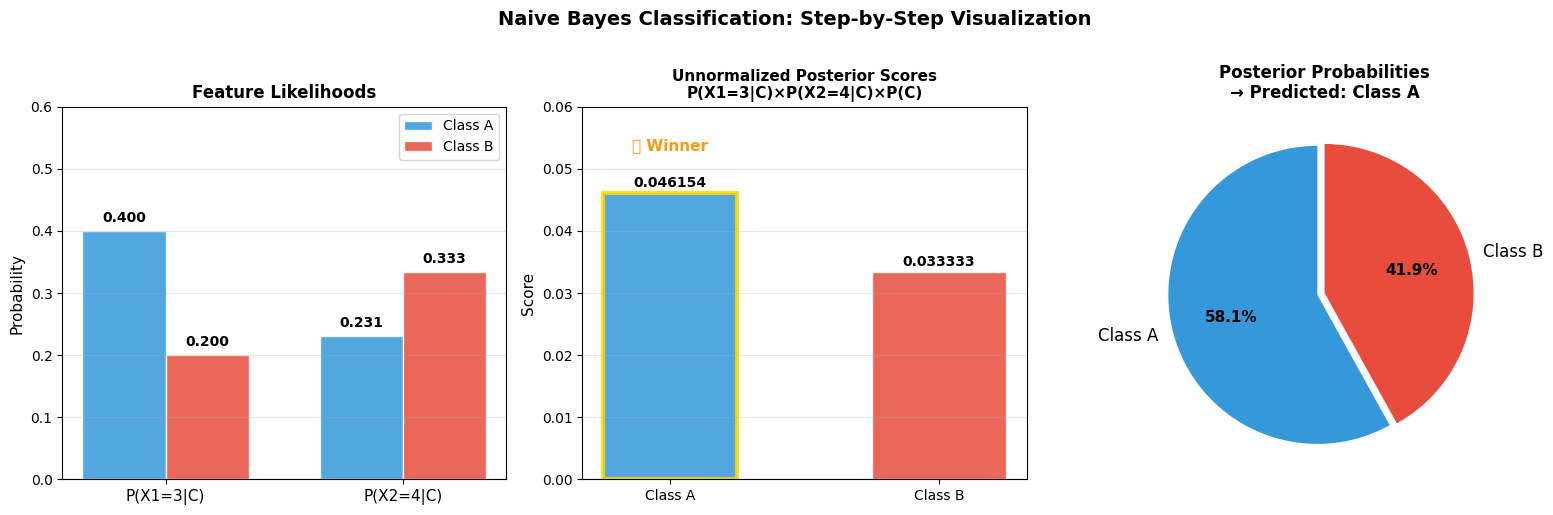

Visualization saved as 'naive_bayes_results.png'


In [11]:
#  STEP 6: Visualization of Results


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Naive Bayes Classification: Step-by-Step Visualization', fontsize=14, fontweight='bold', y=1.02)

COLORS = {'A': '#3498DB', 'B': '#E74C3C'}

# Plot 1: Feature Likelihoods
ax1 = axes[0]
x_groups = ['P(X1=3|C)', 'P(X2=4|C)']
vals_A = [P_X1_3_given_A, P_X2_4_given_A]
vals_B = [P_X1_3_given_B, P_X2_4_given_B]

x = np.arange(len(x_groups))
width = 0.35
bars1 = ax1.bar(x - width/2, vals_A, width, label='Class A', color=COLORS['A'], alpha=0.85, edgecolor='white')
bars2 = ax1.bar(x + width/2, vals_B, width, label='Class B', color=COLORS['B'], alpha=0.85, edgecolor='white')

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('Feature Likelihoods', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(x_groups, fontsize=11)
ax1.set_ylabel('Probability', fontsize=11)
ax1.legend(fontsize=10)
ax1.set_ylim(0, 0.6)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Unnormalized Posterior Scores
ax2 = axes[1]
classes = ['Class A', 'Class B']
scores = [score_A, score_B]
colors = [COLORS['A'], COLORS['B']]

bars = ax2.bar(classes, scores, color=colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, score in zip(bars, scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{score:.6f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_title('Unnormalized Posterior Scores\nP(X1=3|C)×P(X2=4|C)×P(C)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Score', fontsize=11)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(scores) * 1.3)

# Highlight winner
winner_idx = 0 if score_A > score_B else 1
bars[winner_idx].set_edgecolor('gold')
bars[winner_idx].set_linewidth(3)
ax2.text(winner_idx, scores[winner_idx] * 1.15, '⭐ Winner', ha='center', fontsize=11,
         color='#F39C12', fontweight='bold')

# Plot 3: Normalized Posterior Probabilities (Pie)
ax3 = axes[2]
posteriors = [posterior_A, posterior_B]
explode = (0.05, 0) if posterior_A > posterior_B else (0, 0.05)

wedges, texts, autotexts = ax3.pie(
    posteriors,
    labels=['Class A', 'Class B'],
    autopct='%1.1f%%',
    colors=[COLORS['A'], COLORS['B']],
    explode=explode,
    startangle=90,
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(11)
    at.set_fontweight('bold')

ax3.set_title(f'Posterior Probabilities\n→ Predicted: Class {prediction}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('naive_bayes_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved as 'naive_bayes_results.png'")

In [12]:

#  STEP 7: Verification using sklearn


from sklearn.naive_bayes import CategoricalNB
import numpy as np

# Reconstruct dataset from frequency table.
# Features: [X1, X2] — we use 0-indexed categories for sklearn:
#   X1: 1→0, 2→1, 3→2
#   X2: 1→0, 2→1, 3→2, 4→3

# Class A instances (X1 0-indexed)
X1_A = [0]*3 + [1]*3 + [2]*4   # X1=1,2,3 → 0,1,2
X2_A = [0]*4 + [1]*3 + [2]*3 + [3]*3  # X2=1,2,3,4 → 0,1,2,3

# Class B instances (X1 0-indexed)
X1_B = [0]*2 + [1]*2 + [2]*1
X2_B = [0]*2 + [1]*2 + [2]*2 + [3]*3

# Pair X1 and X2 per row (cycle X2 to match X1 length)
X_A = [[x1, x2] for x1, x2 in zip(X1_A, (X2_A * 2)[:len(X1_A)])]
X_B = [[x1, x2] for x1, x2 in zip(X1_B, (X2_B * 2)[:len(X1_B)])]

X_train = np.array(X_A + X_B)
y_train = np.array(['A']*len(X_A) + ['B']*len(X_B))

# Train Categorical Naive Bayes
# min_categories ensures sklearn knows the full range of each feature
# X1 has values 1-3 (3 categories), X2 has values 1-4 (4 categories)
model = CategoricalNB(min_categories=[3, 4])
model.fit(X_train, y_train)

# Predict for X1=3 (→ index 2), X2=4 (→ index 3)
X_new = np.array([[2, 3]])  # 0-indexed: X1=3→2, X2=4→3
predicted_class = model.predict(X_new)[0]
predicted_proba = model.predict_proba(X_new)[0]

print("=" * 55)
print("  SKLEARN CATEGORICAL NAIVE BAYES — VERIFICATION")
print("=" * 55)
print(f"  New Instance  : X1=3, X2=4")
print(f"  Predicted Class : {predicted_class}")
print(f"  Class Probabilities:")
for cls, prob in zip(model.classes_, predicted_proba):
    print(f"    P({cls} | X1=3, X2=4) = {prob:.4f} ({prob:.2%})")
print("=" * 55)
print(f"\n  ✅ sklearn confirms: Predicted Class = {predicted_class}")

  SKLEARN CATEGORICAL NAIVE BAYES — VERIFICATION
  New Instance  : X1=3, X2=4
  Predicted Class : A
  Class Probabilities:
    P(A | X1=3, X2=4) = 0.6642 (66.42%)
    P(B | X1=3, X2=4) = 0.3358 (33.58%)

  ✅ sklearn confirms: Predicted Class = A
